I don't quite know what im doing yet but imma try to get some data about India and try to analyse with GEE api and leafmap

In [2]:
import ee

c:\Users\vacha\miniconda3\envs\geo\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [3]:
#Authentication
#ee.Authenticate()

In [4]:
ee.Initialize()

In [5]:
india = ee.FeatureCollection("FAO/GAUL/2015/level0").filter(ee.Filter.eq("ADM0_NAME", "India"))
indiaGeo = india.geometry()

In [6]:
import geopandas as gpd
import rasterio
import geemap as gm

In [7]:
states = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq("ADM0_NAME", "India"))

In [8]:
m = gm.Map(center=[20, 80], zoom=5)
m

Map(center=[20, 80], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [9]:
m.addLayer(india, {}, "India Boundary")

In [10]:
states.first().propertyNames().getInfo()

['Shape_Leng',
 'ADM1_CODE',
 'STATUS',
 'ADM0_NAME',
 'ADM0_CODE',
 'EXP1_YEAR',
 'Shape_Area',
 'system:index',
 'ADM1_NAME',
 'STR1_YEAR',
 'DISP_AREA']

In [11]:
m.addLayer(states, {}, "Indian States")

In [12]:
indiadf = gm.ee_to_gdf(india)
statesdf = gm.ee_to_gdf(states)

In [13]:
import leafmap as lm

In [14]:
m2 = lm.Map(center=[21, 82], zoom=5)
m2

Map(center=[21, 82], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

In [15]:
m2.add_gdf(indiadf, layer_name = "Indian Border")

In [16]:
#m2.add_data(data = statesdf, column = "ADM1_NAME",  cmap = "nipy_spectral", layer_name = "Indian States", add_legend = False)
#Lets calculate mean NDVI and then color based on that or something 

## Great, we colored the indian states

This took embarassingly long

In [17]:
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(india)

In [18]:
s2Img = s2.filterDate("2022-01-01", "2022-01-15").median()

In [19]:
#looks ugly
m.addLayer(s2Img, {"bands":["B4", "B3", "B2"], "min":300, "max": 2500}, "Raster Image Data")

India too big so looks ugly i guess, let's stop tryna visualize that and do some NDVI statewise analysis or something


In [20]:
#Masking based on good pixels that we want (not clouds or shadows or etc)
def mask(image):
    scl = image.select("SCL")
    valid = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))
    return image.updateMask(valid)

#Computing NDVI 
def ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return image.addBands(ndvi)

In [21]:
s2 = s2.map(mask).map(ndvi)

For each state, i think taking median with respect to time (with timeframe of like an year), and then taking mean with respect to space (the entire state) would give a nice median-with-respect-to-time and mean-with-respect-to-space view of NDVI in each state anually which i think is a good metric to compare the states with

In [22]:
statesdf.head()

,geometry,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,DISP_AREA,EXP1_YEAR,STATUS,STR1_YEAR,Shape_Area,Shape_Leng
0,"POLYGON ((83.31607 25.02734, 83.31818 25.01732...",115,India,70073,Bihar,NO,3000,Member State,2001,8.478177,25.991191
1,"POLYGON ((80.23956 18.75221, 80.2408 18.74869,...",115,India,70075,Chhattisgarh,NO,3000,Member State,2001,11.790087,28.886558
2,"POLYGON ((83.32356 24.10133, 83.3276 24.09965,...",115,India,70078,Jharkhand,NO,3000,Member State,2001,7.084292,26.673495
3,"POLYGON ((74.03467 22.50837, 74.03511 22.50274...",115,India,70079,Madhya Pradesh,NO,3000,Member State,2001,27.246919,62.373589
4,"POLYGON ((77.08491 29.53359, 77.08649 29.52826...",115,India,70081,Uttar Pradesh,NO,3000,Member State,2001,21.884813,52.124451


In [23]:
#need to simplify state polygons because taking wayy too long
statesSimple = states.map(lambda f: f.setGeometry(f.geometry().simplify(1000)))

In [24]:
#Below code for temporal aggregation (median) of ndvi for years 2020-2025

#for i in range(1):

    #d = 2025 + i
    #annualNDVI = (s2.filterDate(f"{d}-01-01", f"{d+1}-01-01").select("NDVI").median())

    #task = ee.batch.Export.image.toDrive(image = annualNDVI, description= f"ndvi_{d}",  region = indiaGeo, scale = 100, maxPixels = 1e13)
    #task.start()

In [25]:
#Get the data into csv

#for i in range(5):
    #d = 2021 + i     
    #ndviImg = ee.Image(f"projects/gee-project-482605/assets/ndvi_{d}")  
    
    #stateNDVI = ndviImg.reduceRegions(collection = statesSimple, reducer = ee.Reducer.mean(), scale = 100)

    #ee.batch.Export.table.toDrive(collection=stateNDVI,description = f"ndvi_states_{d}", fileFormat = "CSV").start()

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [27]:
dfTest = pd.read_csv("./DataCsv/ndvi_states_2020.csv")
dfTest.head()

,system:index,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,DISP_AREA,EXP1_YEAR,STATUS,STR1_YEAR,Shape_Area,Shape_Leng,mean,.geo
0,000000000000000001ef,115,India,70073,Bihar,NO,3000,Member State,2001,8.478177,25.991191,0.435355,"{""type"":""GeometryCollection"",""geometries"":[{""t..."
1,000000000000000001f1,115,India,70075,Chhattisgarh,NO,3000,Member State,2001,11.790087,28.886558,0.471250,"{""type"":""Polygon"",""coordinates"":[[[80.24080104..."
2,000000000000000001f4,115,India,70078,Jharkhand,NO,3000,Member State,2001,7.084292,26.673495,0.456978,"{""type"":""GeometryCollection"",""geometries"":[{""t..."
3,000000000000000001f5,115,India,70079,Madhya Pradesh,NO,3000,Member State,2001,27.246919,62.373589,0.380296,"{""type"":""GeometryCollection"",""geometries"":[{""t..."
4,000000000000000001f7,115,India,70081,Uttar Pradesh,NO,3000,Member State,2001,21.884813,52.124451,0.385277,"{""type"":""GeometryCollection"",""geometries"":[{""t..."


In [28]:
for i in range(6):
    d = 2020 + i
    dfTransfer = pd.read_csv(f"./DataCsv/ndvi_states_{d}.csv")

    mapping = dict(zip(dfTransfer["ADM1_NAME"], dfTransfer["mean"]))

    statesdf[f"ndvi_{d}"] = statesdf["ADM1_NAME"].map(mapping)

In [29]:
statesdf.head()

,geometry,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,DISP_AREA,EXP1_YEAR,STATUS,STR1_YEAR,Shape_Area,Shape_Leng,ndvi_2020,ndvi_2021,ndvi_2022,ndvi_2023,ndvi_2024,ndvi_2025
0,"POLYGON ((83.31607 25.02734, 83.31818 25.01732...",115,India,70073,Bihar,NO,3000,Member State,2001,8.478177,25.991191,0.435355,0.409268,0.413440,0.393757,0.383262,0.417424
1,"POLYGON ((80.23956 18.75221, 80.2408 18.74869,...",115,India,70075,Chhattisgarh,NO,3000,Member State,2001,11.790087,28.886558,0.471250,0.428158,0.444647,0.441713,0.434476,0.448010
2,"POLYGON ((83.32356 24.10133, 83.3276 24.09965,...",115,India,70078,Jharkhand,NO,3000,Member State,2001,7.084292,26.673495,0.456978,0.394571,0.440305,0.391031,0.432524,0.441002
3,"POLYGON ((74.03467 22.50837, 74.03511 22.50274...",115,India,70079,Madhya Pradesh,NO,3000,Member State,2001,27.246919,62.373589,0.380296,0.349113,0.366316,0.370970,0.352414,0.374670
4,"POLYGON ((77.08491 29.53359, 77.08649 29.52826...",115,India,70081,Uttar Pradesh,NO,3000,Member State,2001,21.884813,52.124451,0.385277,0.383620,0.373977,0.387395,0.359361,0.387759


In [30]:
statesdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   geometry    34 non-null     geometry
 1   ADM0_CODE   34 non-null     int64   
 2   ADM0_NAME   34 non-null     object  
 3   ADM1_CODE   34 non-null     int64   
 4   ADM1_NAME   34 non-null     object  
 5   DISP_AREA   34 non-null     object  
 6   EXP1_YEAR   34 non-null     int64   
 7   STATUS      34 non-null     object  
 8   STR1_YEAR   34 non-null     int64   
 9   Shape_Area  34 non-null     float64 
 10  Shape_Leng  34 non-null     float64 
 11  ndvi_2020   34 non-null     float64 
 12  ndvi_2021   34 non-null     float64 
 13  ndvi_2022   34 non-null     float64 
 14  ndvi_2023   34 non-null     float64 
 15  ndvi_2024   34 non-null     float64 
 16  ndvi_2025   34 non-null     float64 
dtypes: float64(8), geometry(1), int64(4), object(4)
memory usage: 4.6+ KB


In [38]:
statesdf["mean_ndvi"] = (statesdf["ndvi_2020"] + statesdf["ndvi_2021"] + statesdf["ndvi_2022"] + statesdf["ndvi_2023"] + statesdf["ndvi_2024"] + statesdf["ndvi_2025"])/6 

In [39]:
statesdf.to_file("statesNDVI.geojson", driver="GeoJSON")

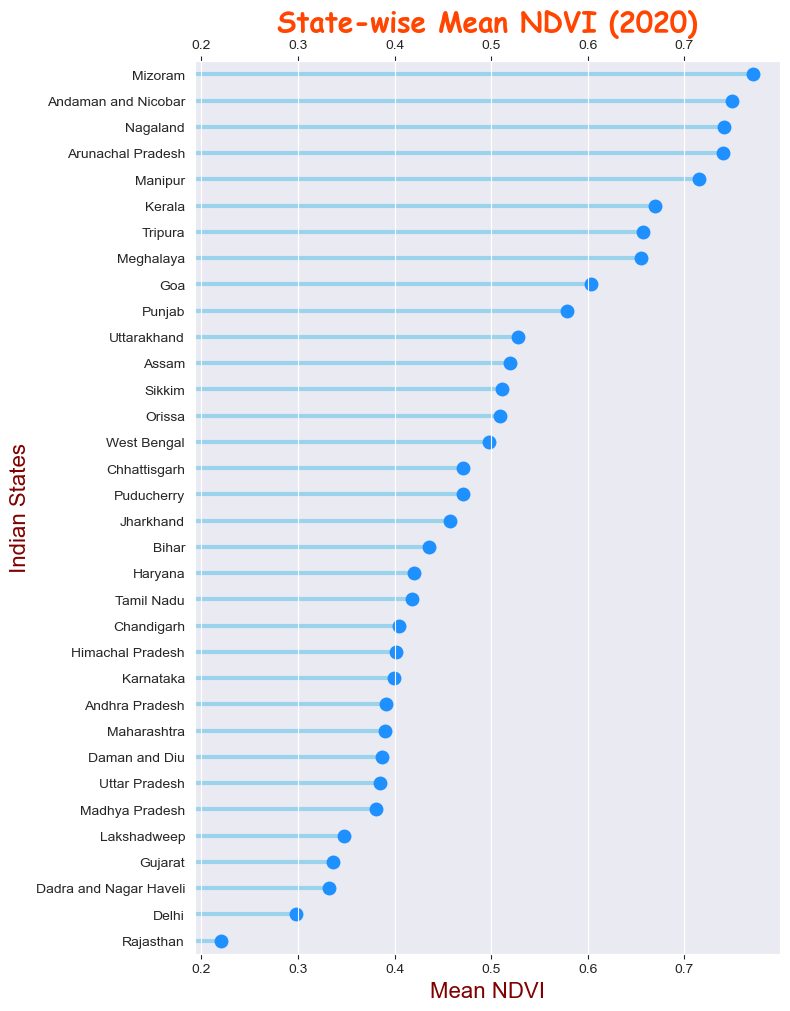

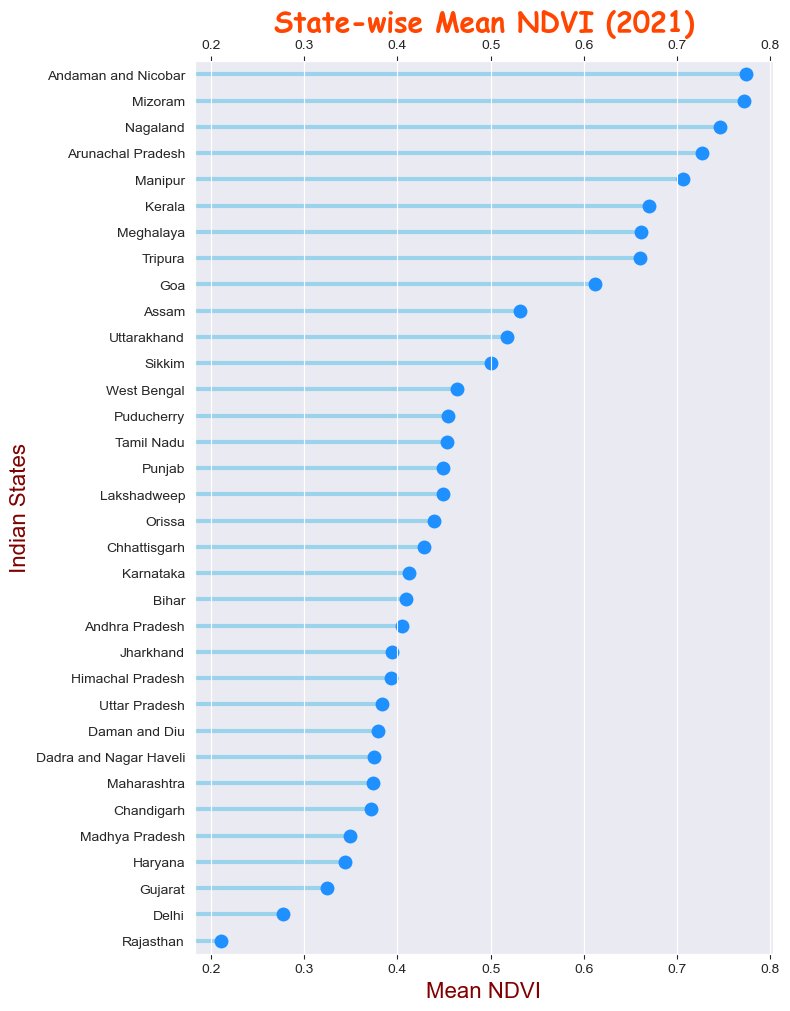

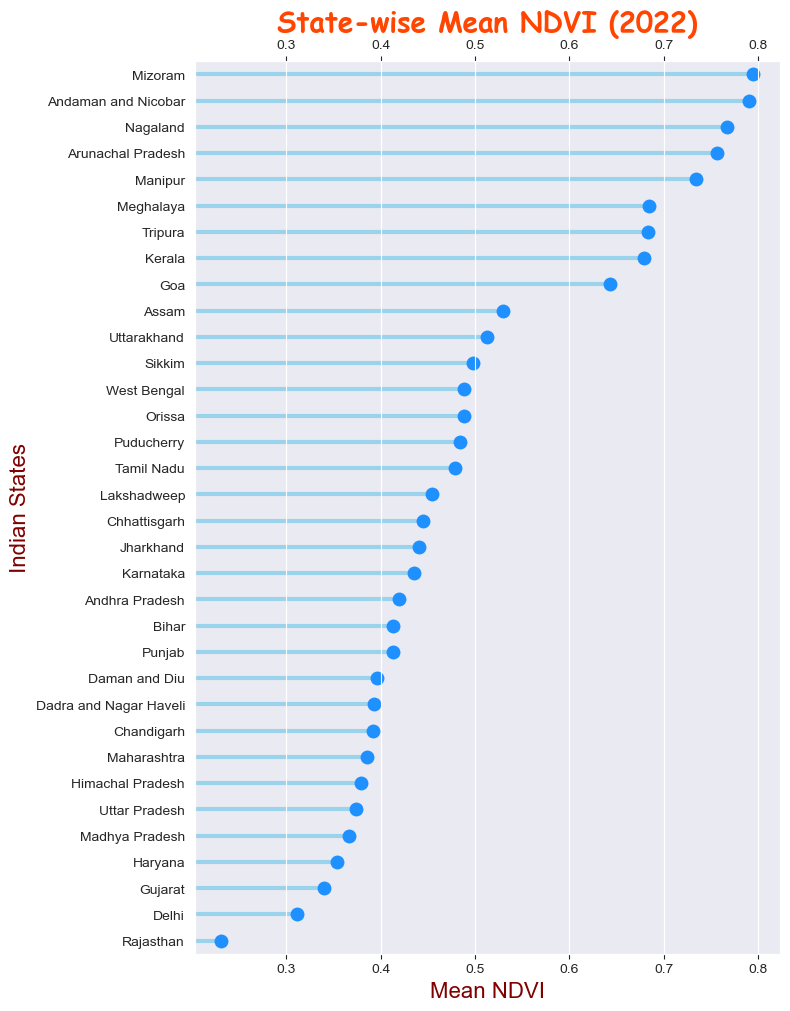

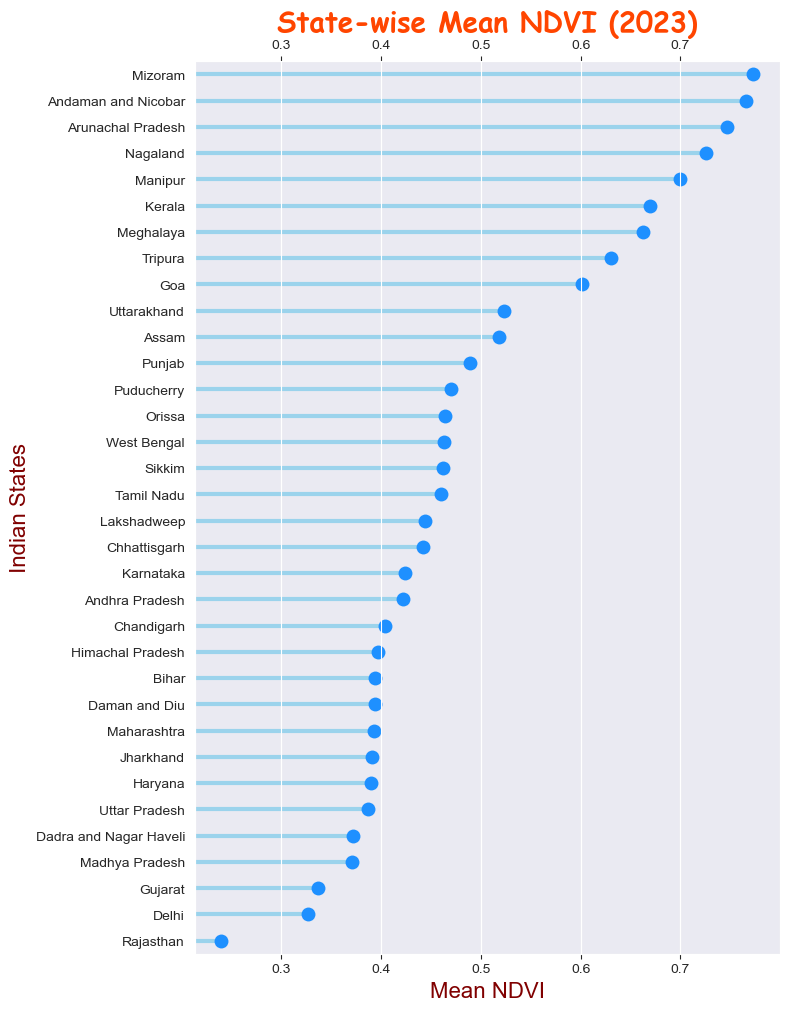

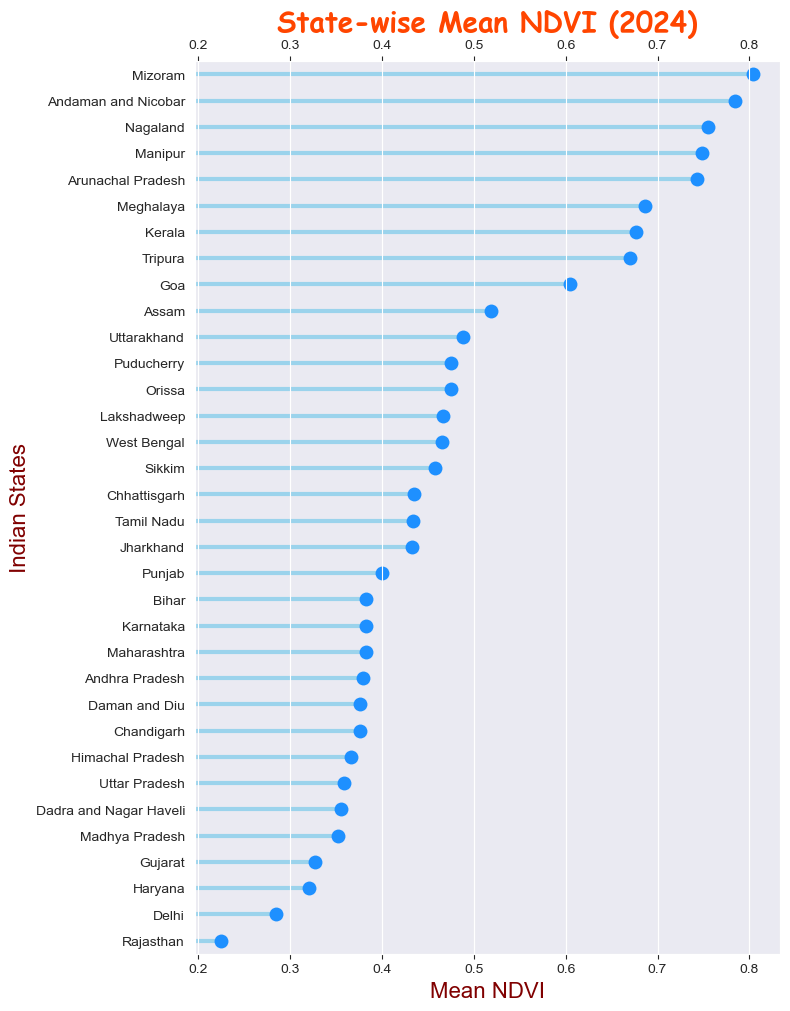

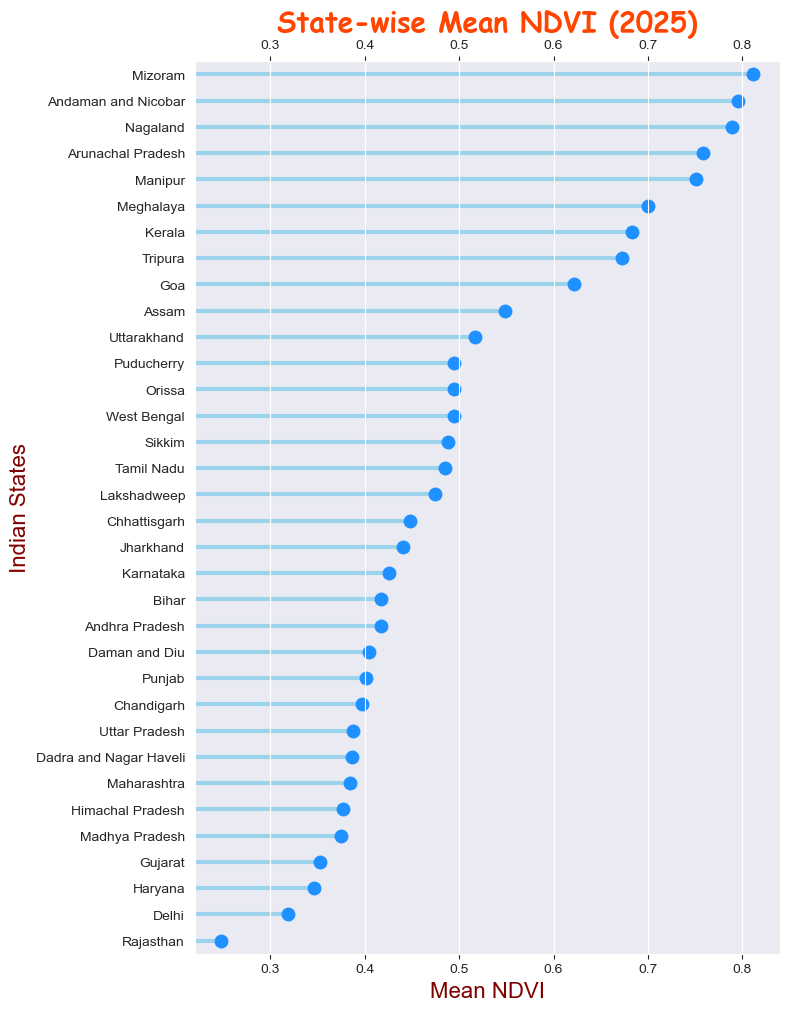

In [42]:
titleFont = {'weight':'bold', 'color':'orangered', 'size':20, 'name':'Comic Sans MS'}
normalFont = {'color':'maroon', 'size':16}

for i in range(6):
    d = 2020 + i

    df = statesdf[["ADM1_NAME", f"ndvi_{d}"]].sort_values(f"ndvi_{d}", ascending=False).reset_index(drop = True)

    plt.figure(figsize=(8, 10), dpi = 100)
    sns.set_style('darkgrid')
    plt.hlines(y = range(len(df)), xmin = 0, xmax = df[f"ndvi_{d}"], color = 'skyblue', alpha = 0.8, linewidth = 3)
    sns.stripplot(x = df[f"ndvi_{d}"], y = df["ADM1_NAME"], size = 10, color = 'dodgerblue')
    plt.xlabel("Mean NDVI", fontdict = normalFont)
    plt.title(f"State-wise Mean NDVI ({d})", fontdict = titleFont)
    plt.ylabel('Indian States', fontdict = normalFont)
    plt.tight_layout()

    ax = plt.gca()
    ax_top = ax.twiny()

    ax_top.set_xlim(ax.get_xlim())
    plt.savefig(f'./YearlyNDVIBar/{d}_bar.png', dpi = 300, bbox_inches="tight")

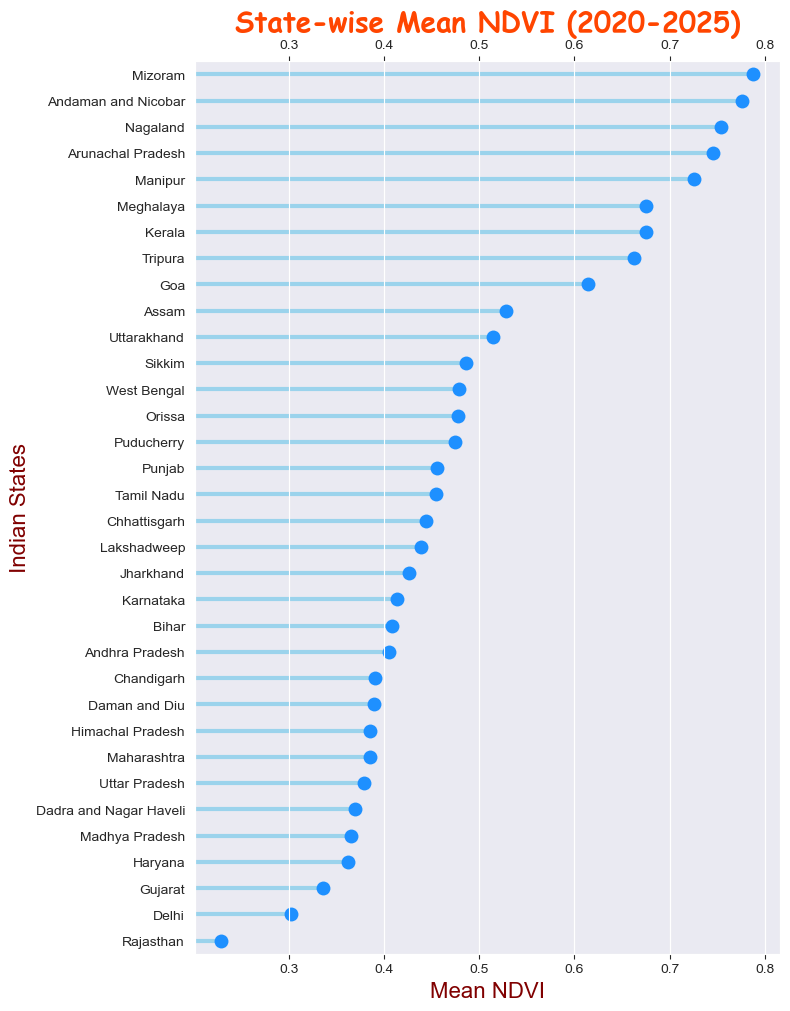

In [43]:
#Temporal median + Spatial mean + mean of the 6 years

df = statesdf[["ADM1_NAME", "mean_ndvi"]].sort_values("mean_ndvi", ascending=False).reset_index(drop = True)

plt.figure(figsize=(8, 10), dpi = 100)
sns.set_style('darkgrid')
plt.hlines(y = range(len(df)), xmin = 0, xmax = df["mean_ndvi"], color = 'skyblue', alpha = 0.8, linewidth = 3)
sns.stripplot(x = df["mean_ndvi"], y = df["ADM1_NAME"], size = 10, color = 'dodgerblue')
plt.xlabel("Mean NDVI", fontdict = normalFont)
plt.title(f"State-wise Mean NDVI (2020-2025)", fontdict = titleFont)
plt.ylabel('Indian States', fontdict = normalFont)
plt.tight_layout()

ax = plt.gca()
ax_top = ax.twiny()

ax_top.set_xlim(ax.get_xlim())
plt.savefig('meanNDVIBar.png', dpi = 300, bbox_inches="tight")